In [99]:
# %%
import sys
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PySide6.QtWidgets import (QApplication, QMainWindow, QWidget, QVBoxLayout, 
                             QHBoxLayout, QFormLayout, QLineEdit, QPushButton, 
                             QLabel, QComboBox, QGroupBox, QScrollArea, QMessageBox)
from PySide6.QtCore import Qt
import xgboost
import lightgbm

# ================== 1. 全局配置 ==================
BASE_PATH = r"C:\Users\GIGABYTE\Desktop\Test\Analysis\新（可用）\CSV"
TARGET_KEYS = ["EUI", "sDA", "sGA", "UDI", "SVF"]
TARGET_DISPLAY = {
    "EUI": "EUI (kWh/m²)",
    "sDA": "sDA<sub>450/50%</sub> (%)",
    "sGA": "sGA<sub>0.35, 5%</sub> (%)",
    "UDI": "UDI<sub>100-2000lx</sub> (%)",
    "SVF": "SVF (%)"
}

FEATURE_ORDER = [
    'WWR_s_exp', 'WWR_s', 'H_s', 'W_s', 'SH_s', 'd_A_s', 'd_B_s',
    'WWR_c', 'H_c', 'W_c', 'SH_c', 'd_A_c', 'd_B_c',
    'F_BL', 'F_BR', 'F_TR', 'F_TL',
    'alpha_oh', 'L_oh', 'd_mv',
    'N_v', 'W_v', 'L_v', 'M_TL', 'M_TR'
]

# 预测模型依然只识别物理参数，不识别 WWR_s_exp
SHADE_FEATURE_MAP = {
    "基准 (Base)": FEATURE_ORDER[1:13],
    "框式 (Frame)": FEATURE_ORDER[1:13] + FEATURE_ORDER[13:17],
    "悬挑 (Overhang)": FEATURE_ORDER[1:13] + FEATURE_ORDER[17:20],
    "垂直 (Vertical)": FEATURE_ORDER[1:13] + FEATURE_ORDER[20:25],
    "组合 (O+V)": FEATURE_ORDER[1:13] + FEATURE_ORDER[17:25]
}

ORI_LIST = ["南向 (South 0°)", "北向 (North 0°)"]
SHADE_LIST = ["基准 (Base)", "悬挑 (Overhang)", "垂直 (Vertical)", "组合 (O+V)", "框式 (Frame)"]

# 论文数据预设 (WWR_s 在这里作为 WWR_s_exp 填入)
PRESET_DATA = {
    (ORI_LIST[0], SHADE_LIST[0]): {'WWR_s':30,'H_s':2,'SH_s':0.9,'WWR_c':15,'H_c':0.9,'W_c':4.5,'SH_c':0.8},
    (ORI_LIST[0], SHADE_LIST[1]): {'WWR_s':30,'H_s':1.2,'SH_s':1,'WWR_c':15,'H_c':1.2,'W_c':3.4,'SH_c':0.8,'alpha_oh':20,'L_oh':1.9,'d_mv':0},
    (ORI_LIST[0], SHADE_LIST[2]): {'WWR_s_exp':31,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'N_v':2,'W_v':1,'L_v':0.1,'M_TL':0,'M_TR':0.2},
    (ORI_LIST[0], SHADE_LIST[3]): {'WWR_s_exp':31,'H_s':1.4,'SH_s':0.8,'WWR_c':20,'H_c':0.9,'W_c':6,'SH_c':0.8,'alpha_oh':50,'L_oh':2,'d_mv':0,'N_v':7,'W_v':0.3,'L_v':0.2,'M_TL':0.15,'M_TR':0},
    (ORI_LIST[0], SHADE_LIST[4]): {'WWR_s':30,'H_s':2,'SH_s':1,'WWR_c':15,'H_c':1,'W_c':4,'SH_c':1,'F_BL':0.7,'F_BR':1.4,'F_TR':1.1,'F_TL':0.9},
    (ORI_LIST[1], SHADE_LIST[0]): {'WWR_s':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2},
    (ORI_LIST[1], SHADE_LIST[1]): {'WWR_s':35,'H_s':2.2,'SH_s':0.8,'WWR_c':15,'H_c':0.9,'W_c':4.5,'SH_c':0.8,'alpha_oh':80,'L_oh':0.4,'d_mv':0.8},
    (ORI_LIST[1], SHADE_LIST[2]): {'WWR_s_exp':40,'H_s':1.9,'SH_s':1,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'N_v':8,'W_v':0.3,'L_v':0.1,'M_TL':0.1,'M_TR':0},
    (ORI_LIST[1], SHADE_LIST[3]): {'WWR_s_exp':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.6,'W_c':4.5,'SH_c':2,'alpha_oh':-80,'L_oh':1.5,'d_mv':0.5,'N_v':5,'W_v':0.02,'L_v':0.1,'M_TL':0,'M_TR':0},
    (ORI_LIST[1], SHADE_LIST[4]): {'WWR_s':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'F_BL':0.1,'F_BR':0.4,'F_TR':0.1,'F_TL':0.1}
}

In [100]:
# %% [修改 Cell 2：W_s 保留1位，WWR_s 取整]
def geometry_engine(ui, mode):
    wa = 27.0  # 9x3 墙面积
    wl = 9.0   # 墙长
    hs = float(ui.get('H_s', 2.0))
    wv = float(ui.get('W_v', 0.1)) 

    if mode in ["垂直 (Vertical)", "组合 (O+V)"]:
        # 1. 获取输入：设计意图 WWR_exp 和 构件数
        nv = max(2, int(float(ui.get('N_v', 2))))
        wwr_exp = float(ui.get('WWR_s_exp', 30))
        
        # 2. 计算理论开洞总宽
        total_area_theory = (wwr_exp / 100.0) * wa
        total_w_theory = total_area_theory / hs
        if total_w_theory > wl: total_w_theory = wl

        # 3. 计算理论净玻璃总宽 (基于 N-1 逻辑)
        net_glass_w_theory = max(0.1, total_w_theory - (nv - 1) * wv)
        
        # 4. 计算单扇窗宽并【四舍五入到 1 位小数】
        ws_pane_raw = net_glass_w_theory / (nv - 1)
        ws_pane = round(ws_pane_raw, 1) 
        
        # 5. 【回算】基于舍入后的 ws_pane 计算实际净玻璃面积
        net_glass_w_actual = ws_pane * (nv - 1)
        
        # 6. 【回算】计算实际 WWR_s 并【四舍五入取整】
        # 例如：30.81 -> 31, 30.49 -> 30
        actual_wwr = round((net_glass_w_actual * hs / wa) * 100.0)
        
    else:
        # 非垂直模式逻辑（Base, Overhang, Frame）
        nv = 0
        actual_wwr_input = float(ui.get('WWR_s', 30))
        # 同样执行 W_s 舍入和 WWR_s 取整以保持物理一致性
        net_glass_w_theory = (actual_wwr_input / 100.0) * wa / hs
        ws_pane = round(net_glass_w_theory, 1)
        actual_wwr = round((ws_pane * hs / wa) * 100.0)

    # 封装结果
    res = {k: float(ui.get(k, 0)) for k in FEATURE_ORDER}
    res.update({
        'WWR_s': int(actual_wwr),  # 强制转换为整数显示
        'W_s': ws_pane,           # 保留 1 位小数
        'N_v': nv
    })
    return res

## Cell 3a: 3D 物理绘图引擎 (Visualization Engine)


In [101]:
# %%
def draw_classroom_3d(ax, data, sha_mode):
    """
    专门负责 3D 几何绘制的独立函数
    补充：走廊地坪、走廊吊顶(3.0-3.8m)、走廊侧窗
    """
    ax.clear()
    L, D, H_total = 9.0, 9.0, 3.8 

    # --- 1. 视觉纠偏：正交投影 + 1:1 比例锁定 ---
    ax.set_proj_type('ortho') 
    span = 14                 
    ax.set_xlim(-4, 10)       
    ax.set_ylim(-2.5, 11.5)   
    ax.set_zlim(0, 5)
    ax.set_box_aspect((span, span, H_total)) 
    ax.set_axis_off()

    # --- 2. 绘制主体框架 (室内 3.8m 无吊顶) ---
    for z in [0, H_total]:
        ax.plot3D([0,9,9,0,0],[0,0,9,9,0],[z,z,z,z,z], 'black', lw=1.5)
    for x, y in [(0,0),(9,0),(9,9),(0,9)]:
        ax.plot3D([x,x],[y,y],[0,H_total], 'k', lw=1, alpha=0.4)

    # --- 3. 走廊侧构造 (X=0 墙面及 X<0 空间) ---
    # A. 走廊地坪 (X: -3 to 0)
    corr_floor = [[(-3, 0, 0), (0, 0, 0), (0, 9, 0), (-3, 9, 0)]]
    ax.add_collection3d(Poly3DCollection(corr_floor, facecolors='gray', alpha=0.1))

    # B. 走廊吊顶/静压箱 (3.0m - 3.8m)
    # 绘制底面(3.0m)和顶面(3.8m)
    c_plenum = [
        [(-3, 0, 3.0), (0, 0, 3.0), (0, 9, 3.0), (-3, 9, 3.0)], # 吊顶底
        [(-3, 0, 3.8), (0, 0, 3.8), (0, 9, 3.8), (-3, 9, 3.8)]  # 走廊顶
    ]
    ax.add_collection3d(Poly3DCollection(c_plenum, facecolors='gray', alpha=0.3))

    # C. 走廊侧窗户 (Window_C)
    wc = data.get('W_c', 4.0)
    hc = data.get('H_c', 1.0)
    shc = data.get('SH_c', 1.0)
    yc_start = (D - wc) / 2
    win_c_verts = [[(0, yc_start, shc), (0, yc_start+wc, shc), (0, yc_start+wc, shc+hc), (0, yc_start, shc+hc)]]
    ax.add_collection3d(Poly3DCollection(win_c_verts, facecolors='lightgreen', edgecolors='g', alpha=0.5, lw=1))

    # D. 走廊侧双门 (已有的逻辑)
    for yd in [0.2, 9-0.2-1.2]:
        dr = [[(0, yd, 0), (0, yd+1.2, 0), (0, yd+1.2, 2.2), (0, yd, 2.2)]]
        ax.add_collection3d(Poly3DCollection(dr, facecolors='saddlebrown', edgecolors='k', alpha=0.8))

    # --- 4. 南侧窗户分格绘制 (X=9) ---
    is_v = "垂直" in sha_mode or "组合" in sha_mode
    nv = int(data.get('N_v', 0))
    wv = data.get('W_v', 0.1)
    ws_pane = data.get('W_s', 4.0)
    hs = data.get('H_s', 2.0)
    shs = data.get('SH_s', 0.9)

    if is_v and nv >= 2:
        num_p = nv - 1
        total_opening_w = (num_p * ws_pane) + (nv - 1) * wv
    else:
        num_p = 1
        total_opening_w = ws_pane
    
    ys_start = (D - total_opening_w) / 2

    for i in range(num_p):
        if is_v and nv >= 2:
            curr_y = ys_start + wv/2 + i * (ws_pane + wv)
        else:
            curr_y = ys_start
        pane = [[(9, curr_y, shs), (9, curr_y+ws_pane, shs), (9, curr_y+ws_pane, shs+hs), (9, curr_y, shs+hs)]]
        ax.add_collection3d(Poly3DCollection(pane, facecolors='skyblue', edgecolors='b', alpha=0.5))

    # --- 5. 垂直遮阳绘制 ---
    if is_v and nv > 0:
        lv, mtl, mtr = data.get('L_v', 0), data.get('M_TL', 0), data.get('M_TR', 0)
        for i in range(nv):
            by = ys_start + i * (ws_pane + wv)
            p1, p2 = (9, by - wv/2, 0), (9, by + wv/2, 0)
            p3, p4 = (9, by + wv/2, 3.8), (9, by - wv/2, 3.8)
            p5 = (9 + lv, by - wv/2 + mtl, 0)
            p6 = (9 + lv, by + wv/2 - mtr, 0)
            p7 = (9 + lv, by + wv/2 - mtr, 3.8)
            p8 = (9 + lv, by - wv/2 + mtl, 3.8)
            ax.add_collection3d(Poly3DCollection([[p1,p2,p3,p4],[p5,p6,p7,p8],[p1,p5,p8,p4],[p2,p6,p7,p3],[p1,p2,p6,p5],[p4,p3,p7,p8]], facecolors='teal', alpha=0.8, edgecolors='k', lw=0.3))

    # --- 6. 悬挑遮阳 (通长 9m) ---
    if ("悬挑" in sha_mode or "组合" in sha_mode) and data.get('L_oh', 0) > 0:
        alpha, loh, dmv = np.radians(data.get('alpha_oh', 0)), data['L_oh'], data.get('d_mv', 0)
        zt = 3.8 - dmv
        z_end = zt - loh * np.sin(alpha)
        x_ext = 9 + loh * np.cos(alpha)
        oh_verts = [[(9, 0, zt), (x_ext, 0, z_end), (x_ext, 9, z_end), (9, 9, zt)]]
        ax.add_collection3d(Poly3DCollection(oh_verts, facecolors='indianred', alpha=0.8, edgecolors='darkred', lw=0.5))

    # 8. 框式遮阳绘制
    if "框式" in sha_mode:
        fbl, fbr, ftr, ftl = data.get('F_BL',0), data.get('F_BR',0), data.get('F_TR',0), data.get('F_TL',0)
        p_bl, p_br = (9, ys_start, shs), (9, ys_start+total_opening_w, shs)
        p_tr, p_tl = (9, ys_start+total_opening_w, shs+hs), (9, ys_start, shs+hs)
        e_bl, e_br = (9+fbl, ys_start, shs), (9+fbr, ys_start+total_opening_w, shs)
        e_tr, e_tl = (9+ftr, ys_start+total_opening_w, shs+hs), (9+ftl, ys_start, shs+hs)
        ax.add_collection3d(Poly3DCollection([[p_bl, p_br, e_br, e_bl], [p_br, p_tr, e_tr, e_br], [p_tr, p_tl, e_tl, e_tr], [p_tl, p_bl, e_bl, e_tl]], facecolors='orange', alpha=0.7, edgecolors='darkorange'))

    # --- 9. 最终文字标注 ---
    ax.text(9, 4.5, 4.1, f"Actual WWR: {data['WWR_s']}%", color='darkred', fontweight='bold', ha='center')
    ax.view_init(elev=25, azim=45)

## Cell 3b: GUI 控制中心 (Application logic)

In [102]:
# %%
class ClassroomPredictorApp(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("青少年健康教室性能智能预测系统 - 建筑同步版")
        self.resize(1500, 950)
        self.model_map, self.model_cache, self.inputs, self.rows = {}, {}, {}, {}
        self.scan_folders()
        self.init_ui()
        self.apply_presets()

    def scan_folders(self):
        if not os.path.exists(BASE_PATH): return
        folders = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
        for f in folders:
            ori = ORI_LIST[0] if "South0°" in f else (ORI_LIST[1] if "North0°" in f else None)
            if not ori: continue
            sha = SHADE_LIST[0]
            if "Overhang+Vertical" in f: sha = SHADE_LIST[3]
            elif "Overhang" in f: sha = SHADE_LIST[1]
            elif "Vertical" in f: sha = SHADE_LIST[2]
            elif "Frame" in f: sha = SHADE_LIST[4]
            self.model_map[(ori, sha)] = os.path.join(BASE_PATH, f)

    def init_ui(self):
        main_widget = QWidget(); self.setCentralWidget(main_widget)
        main_layout = QHBoxLayout(main_widget)
        # 左侧控制面板
        scroll = QScrollArea(); scroll.setFixedWidth(400); left_box = QWidget(); vbox = QVBoxLayout(left_box)
        grp_sel = QGroupBox("1. 策略选择"); f_sel = QFormLayout()
        self.cb_ori, self.cb_sha = QComboBox(), QComboBox()
        self.cb_ori.addItems(ORI_LIST); self.cb_sha.addItems(SHADE_LIST)
        self.cb_ori.currentTextChanged.connect(self.apply_presets)
        self.cb_sha.currentTextChanged.connect(self.apply_presets)
        f_sel.addRow("朝向:", self.cb_ori); f_sel.addRow("形式:", self.cb_sha)
        grp_sel.setLayout(f_sel); vbox.addWidget(grp_sel)

        grp_param = QGroupBox("2. 设计变量"); self.param_form = QFormLayout()
        for f in FEATURE_ORDER:
            lbl = QLabel(f"{f}:"); edit = QLineEdit("0")
            self.inputs[f] = edit; self.param_form.addRow(lbl, edit); self.rows[f] = (lbl, edit)
        grp_param.setLayout(self.param_form); vbox.addWidget(grp_param)

        self.btn_run = QPushButton("⚡ 执行 Stacking 集成预测"); self.btn_run.setFixedHeight(50)
        self.btn_run.setStyleSheet("background-color: #2c3e50; color: white; font-weight: bold;")
        self.btn_run.clicked.connect(self.do_prediction); vbox.addWidget(self.btn_run)
        scroll.setWidget(left_box); scroll.setWidgetResizable(True); main_layout.addWidget(scroll)

        # 右侧显示面板
        right_box = QVBoxLayout(); res_grp = QGroupBox("预测看板"); res_grid = QHBoxLayout(); self.res_labels = {}
        for key in TARGET_KEYS:
            v = QVBoxLayout(); title = QLabel(TARGET_DISPLAY[key]); title.setAlignment(Qt.AlignCenter)
            lbl = QLabel("--"); lbl.setAlignment(Qt.AlignCenter); lbl.setStyleSheet("font-size: 20px; font-weight: bold; color: #d35400;")
            self.res_labels[key] = lbl; v.addWidget(title); v.addWidget(lbl); res_grid.addLayout(v)
        res_grp.setLayout(res_grid); right_box.addWidget(res_grp)
        self.fig = plt.figure(figsize=(9, 9)); self.ax = self.fig.add_subplot(111, projection='3d')
        self.canvas = FigureCanvas(self.fig); right_box.addWidget(self.canvas)
        main_layout.addLayout(right_box)

    def apply_presets(self):
        """核心输入逻辑切换控制"""
        ori, sha = self.cb_ori.currentText(), self.cb_sha.currentText()
        preset = PRESET_DATA.get((ori, sha), {})
        for feat, val in preset.items():
            if feat in self.inputs: self.inputs[feat].setText(str(val))
        
        active = SHADE_FEATURE_MAP.get(sha, FEATURE_ORDER)
        # 判定是否为参数化模式
        is_param_mode = sha in ["垂直 (Vertical)", "组合 (O+V)"]

        for f, (lbl, edit) in self.rows.items():
            # 1. WWR_s_exp 只在垂直/组合模式下出现
            if f == 'WWR_s_exp':
                lbl.setVisible(is_param_mode); edit.setVisible(is_param_mode)
            else:
                lbl.setVisible(f in active); edit.setVisible(f in active)
            
            # 2. 锁定控制
            if f == 'W_s': 
                edit.setReadOnly(True); edit.setStyleSheet("background-color: #f8f9fa; color: #2980b9; font-weight:bold;")
            elif f == 'WWR_s':
                edit.setReadOnly(is_param_mode) # 参数化模式下 WWR_s 禁止手填
                edit.setStyleSheet(f"background-color: {'#ecf0f1' if is_param_mode else 'white'};")

    def do_prediction(self):
        """执行预测：确保使用回算后的 WWR_s 进行模型输入"""
        # 获取当前选择
        ori_name = self.cb_ori.currentText()
        sha_mode = self.cb_sha.currentText()
        
        # 匹配模型文件夹 (Key 必须与 scan_folders 存入时一致)
        folder = self.model_map.get((ori_name, sha_mode))
        if not folder:
            QMessageBox.warning(self, "缺失模型", f"未找到路径: {ori_name} - {sha_mode}")
            return
        
        try:
            self.btn_run.setEnabled(False); QApplication.processEvents()
            
            # 1. 抓取 UI 原始输入
            raw_in = {f: float(self.inputs[f].text()) for f in FEATURE_ORDER}
            
            # 2. 调用几何引擎 (Cell 2)
            # 计算流程：WWR_s_exp -> W_s(1位) -> WWR_s(取整)
            cal_data = geometry_engine(raw_in, sha_mode)
            
            # 3. 将计算结果写回 UI 界面（实现数值同步）
            self.inputs['W_s'].setText(str(cal_data['W_s']))
            if sha_mode in ["垂直 (Vertical)", "组合 (O+V)"]:
                self.inputs['WWR_s'].setText(str(int(cal_data['WWR_s'])))
            
            # 4. 【关键：特征对齐】构造预测特征向量 X
            # 根据 SHADE_FEATURE_MAP，垂直/组合模式下不含 WWR_s_exp，而是使用 WWR_s
            active_feats = SHADE_FEATURE_MAP.get(sha_mode, FEATURE_ORDER[1:13])
            
            # 这里 cal_data[f] 取到的是经过舍入和取整后的物理参数
            X = np.array([[cal_data[f] for f in active_feats]])
            
            # 5. 加载模型并预测 (Stacking 逻辑)
            ckey = (ori_name, sha_mode)
            if ckey not in self.model_cache:
                self.model_cache[ckey] = {
                    f"{t}_{m}": joblib.load(os.path.join(folder, f"{m}_model_{t}.joblib")) 
                    for t in TARGET_KEYS for m in ["xgb", "lgbm", "rf", "meta"]
                }
            
            mc = self.model_cache[ckey]
            for t in TARGET_KEYS:
                # 获取三个基模型预测值
                m1 = mc[f"{t}_xgb"].predict(X)
                m2 = mc[f"{t}_lgbm"].predict(X)
                m3 = mc[f"{t}_rf"].predict(X)
                # 使用 Meta 模型进行融合
                final = mc[f"{t}_meta"].predict(np.column_stack([m1, m2, m3]))[0]
                
                # 结果处理：除了 EUI，其他通常是百分比或系数
                v_show = final * 100 if t != "EUI" and final <= 1.05 else final
                self.res_labels[t].setText(f"{v_show:.2f}")

            # 6. 更新 3D 绘图
            draw_classroom_3d(self.ax, cal_data, sha_mode)
            self.canvas.draw()
            
            self.btn_run.setEnabled(True)
            
        except Exception as e:
            import traceback; traceback.print_exc()
            QMessageBox.critical(self, "运行故障", f"错误详情: {str(e)}")
            self.btn_run.setEnabled(True)

d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anacon

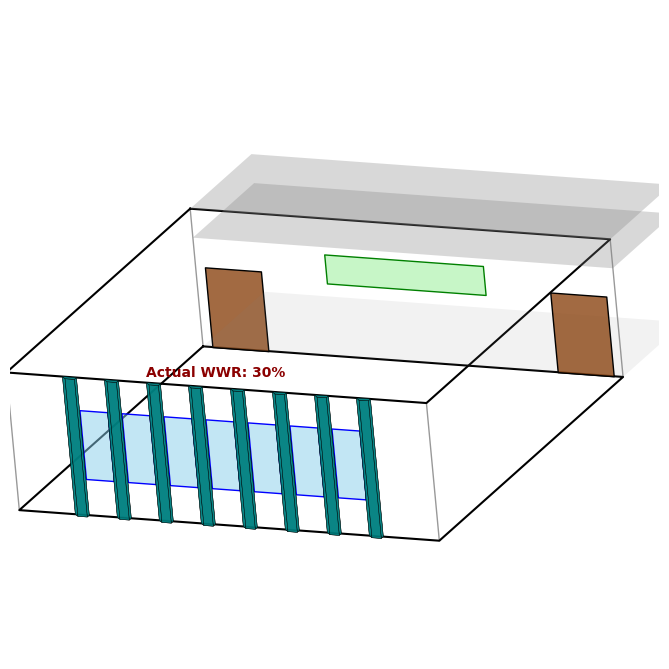

In [103]:
# %%
if __name__ == "__main__":
    app = QApplication.instance() or QApplication(sys.argv)
    main_win = ClassroomPredictorApp()
    main_win.show()
    app.exec()